
## 01MIAR - Actividad Video Valencia Pollution

## NumPy y Pandas

### Objetivos:
- Aplicar diferentes técnicas de tratamiento de estructuras numéricas con Numpy y datos estructurados con Pandas.

### Instrucciones:
- Mantener una estructura limpia, comentando código y secuenciando los apartados con el código correspondiente que resuelva la actividad.
- Como criterio de evaluación se tendrá en cuenta el resultado, la consecución del mismo, estilo, comentarios y adecuación. Siempre será tenido en cuenta cualquier detalle técnico avanzado o no visto en clase relacionado con el tema (explicar el porqué y usabilidad).
- No está permitido compartir los resultados ni el código en ninguno de los foros.
- Revisar los temas así como las sesiones sobre Numpy y Pandas para aplicar dichos contenidos.
- Proponer las respuestas en las celdas a dicho efecto en cada punto, si se necesitan más celdas añadirlas en su sitio correspondiente
- Mostrar de manera clara la respuesta a las preguntas, mediante código

### Entrega:
- Este mismo notebook con las respuetas

### Evaluación
- Esta actividad corresponde con el 10% de la nota final de la asignatura.

### Fecha Realización
- Convocatoria 1 - 05/12/2025 00:00 - 08/12/2024 23:59 (Hora España)

#### Descripción
El conjunto de datos "valencia_pollution_dataset.csv" (fichero disponible adjunto a la actividad) proviene de una descarga de datos del servicio web del ayuntamiento de la ciudad de Valencia de datos abiertos.

Los datos recabados de este servicio web son de mediciones cada hora de una serie de estaciones de contaminación atmosférica.

https://valencia.opendatasoft.com/explore/dataset/estacions-contaminacio-atmosferiques-estaciones-contaminacion-atmosfericas/information/

Cada estación realiza una serie de mediciones acerca de la calidad del aire, y de ciertas sustancias que se consideran importantes para analizar la contaminación atmosférica en la ciudad.

#### Columnas para trabajar:
- objectid: id de la estación
- nombre: nombre de la estación
- dirección: dirección de la estación
- tipozona: tipo de la zona, urbana o sub urbana
- parámetros: parámetroe medidos
- mediciones: fichero de mediciones
- tipoemision: tráfico o fondo
- so2: niveles de dióxido de azufre
- no2: niveles de dióxido de nitrogeno
- o3: niveles de ozono
- co: niveles de monóxido de carbono
- pm10: niveles de partículas en suspensión hasta 10um
- pm25: niveles de partículas en suspensión hasta 2,5um
- fecha_carga: timestamp de la actualización de los datos. (Sugerencia: cambiar a tipo `datetime`)
- calidad_ambiental: estimación de la calidad del aire
- fiwareid: 
- geo_shape: coordenadas geográficas
- geo_point_2d: latitud-longitud

In [85]:
# He creado un ambiente virtual llamado .venv para las librerias que se requieren en el proyecto
# usando el comando python -m venv .venv
# luego he activado el ambiente virtual usando el comando source .venv/scripts/activate
# y he instalado las librerias necesarias usando el comando pip install pandas matplotlib jupyter
# he creado un archivo requirements.txt usando el comando pip freeze > requirements.txt, el cual tene las librerias necesarias para el proyecto
import pandas as pd
import matplotlib.pyplot as plt

## 01
Carga de datos de csv (valencia_pollution_dataset.csv) en un DataFrame

In [86]:
df = pd.read_csv('valencia_pollution_dataset.csv')
print(df.head()) # para poder visualizar los primeros registros del dataset

   objectid          nombre                              direccion tipozona  \
0        26  Pista de Silla                      C/ Filipinas, s/n   Urbana   
1        28         Viveros                    Jardines de Viveros   Urbana   
2       431       Olivereta  Av. del Cid amb Av. de les Tres Creus   Urbana   
3       432         Patraix                Archiduque Carlos, 84ac   Urbana   
4        23         Francia                   Avda. de Francia, 60   Urbana   

   parametros  mediciones  so2  no2    o3   co  pm10  pm25 tipoemision  \
0         NaN         NaN  0.0   10  71.0  0.7   8.0   3.0     Tráfico   
1         NaN         NaN  0.0    5  88.0  NaN   NaN   NaN       Fondo   
2         NaN         NaN  NaN   24   NaN  NaN  20.0  11.0     Tráfico   
3         NaN         NaN  NaN   15   NaN  NaN  20.0  11.0     Tráfico   
4         NaN         NaN  1.0    3  82.0  0.1   9.0   6.0     Tráfico   

                 fecha_carga     calidad_ambiental  fiwareid  geo_shape  \
0  20

In [87]:
df.shape # Verifico la cantidad de filas y columnas del dataset

(396, 18)

In [88]:
df.info() # con este puedo observar el tipo de datos y si hay valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   objectid           396 non-null    int64  
 1   nombre             396 non-null    object 
 2   direccion          396 non-null    object 
 3   tipozona           396 non-null    object 
 4   parametros         0 non-null      float64
 5   mediciones         0 non-null      float64
 6   so2                216 non-null    float64
 7   no2                396 non-null    int64  
 8   o3                 216 non-null    float64
 9   co                 108 non-null    float64
 10  pm10               288 non-null    float64
 11  pm25               288 non-null    float64
 12  tipoemision        396 non-null    object 
 13  fecha_carga        396 non-null    object 
 14  calidad_ambiental  396 non-null    object 
 15  fiwareid           0 non-null      float64
 16  geo_shape          0 non-n

In [89]:
# debido a que se observan columnas con valores nulos, voy a verificar que toda la columna este vacia para proceder a eliminarla
null_columns = df.columns[df.isnull().all()] # con esto obtengo las columnas que tienen todos los valores nulos
type(null_columns) # esto es un Index, por lo que lo convierto a lista para poder eliminar las columnas
print("Columnas con todos los valores nulos:", null_columns.tolist())

Columnas con todos los valores nulos: ['parametros', 'mediciones', 'fiwareid', 'geo_shape', 'geo_point_2d']


In [90]:
# Realizo una doble verificacion sobre una columna especifica para validar que todos sean nulos
nulls = df['parametros'].notna().sum() # cuento los valores que no son nulos en la columna SO2_MN
print("Cantidad de valores no nulos en la columna SO2_MN:", nulls)


Cantidad de valores no nulos en la columna SO2_MN: 0


In [91]:
# Es buena practica limpiar la data eliminando las columnas que no aportan informacion
# podria eliminar individual haciendo df.drop(columns=['parametros', 'mediciones'], inplace=True) y seteando inplace=True para que se actualice el df original
# pero en este caso lo hago de forma automatica
df_cleaned = df.drop(columns=null_columns.tolist()) # elimino las columnas que tienen todos los valores nulos
print("Columnas despues de la limpieza: \n", df_cleaned.head())


Columnas despues de la limpieza: 
    objectid          nombre                              direccion tipozona  \
0        26  Pista de Silla                      C/ Filipinas, s/n   Urbana   
1        28         Viveros                    Jardines de Viveros   Urbana   
2       431       Olivereta  Av. del Cid amb Av. de les Tres Creus   Urbana   
3       432         Patraix                Archiduque Carlos, 84ac   Urbana   
4        23         Francia                   Avda. de Francia, 60   Urbana   

   so2  no2    o3   co  pm10  pm25 tipoemision                fecha_carga  \
0  0.0   10  71.0  0.7   8.0   3.0     Tráfico  2025-05-24T20:20:06+00:00   
1  0.0    5  88.0  NaN   NaN   NaN       Fondo  2025-05-24T20:20:08+00:00   
2  NaN   24   NaN  NaN  20.0  11.0     Tráfico  2025-05-24T20:20:11+00:00   
3  NaN   15   NaN  NaN  20.0  11.0     Tráfico  2025-05-24T20:20:12+00:00   
4  1.0    3  82.0  0.1   9.0   6.0     Tráfico  2025-05-24T20:20:04+00:00   

      calidad_ambiental  
0

In [92]:
# Ahora se observa que hay datos de filas con valores NaN, por lo cual seria prudente verificar como afectan cada columna
# una forma sencilla es observar la cantidad de valores nulos por columna
null_counts = df_cleaned.isnull().sum() # uso sum como agregacion para contar los valores nulos por columna
print("Cantidad de valores nulos por columna:\n", null_counts)

Cantidad de valores nulos por columna:
 objectid               0
nombre                 0
direccion              0
tipozona               0
so2                  180
no2                    0
o3                   180
co                   288
pm10                 108
pm25                 108
tipoemision            0
fecha_carga            0
calidad_ambiental      0
dtype: int64


In [93]:
# Como veo que hay varios datos nulos en diferentes columnas, creo una tabla que me resuma el total de datos contral los nulos por columna
null_summary = pd.DataFrame({'Total Values': df_cleaned.shape[0], 'Null Values': null_counts}) # shape con posicion 0 para discriminar las filas
null_summary

,Total Values,Null Values
objectid,396,0
nombre,396,0
direccion,396,0
tipozona,396,0
so2,396,180
no2,396,0
o3,396,180
co,396,288
pm10,396,108
pm25,396,108


In [94]:
# Ahora verifico que no existan valores duplicados en el dataset
duplicate_count = df_cleaned.duplicated().sum() # este comprueba los duplicados en las filas y los suma, para ello deben coincidir todos los valores de la fila
print("Cantidad de filas duplicadas en el dataset:", duplicate_count)

Cantidad de filas duplicadas en el dataset: 0


In [95]:
# Como no hay filas duplicaddas, continuo con calcular el % de datos nulos por columna para ver su influencia en las metricas
null_summary_contribution = pd.DataFrame({'Total Values': df_cleaned.shape[0], 'Null Values': null_counts,
                                         'Null Percentage': (null_counts / df_cleaned.shape[0]) * 100})
null_summary_contribution

,Total Values,Null Values,Null Percentage
objectid,396,0,0.000000
nombre,396,0,0.000000
direccion,396,0,0.000000
tipozona,396,0,0.000000
so2,396,180,45.454545
no2,396,0,0.000000
o3,396,180,45.454545
co,396,288,72.727273
pm10,396,108,27.272727
pm25,396,108,27.272727


In [96]:
# Como los porcentajes observados son altos, tomare la estretagia de interpolar los datos para completar los valores nulos
df_cleaned.interpolate(method='linear', limit_direction='both', inplace=True) # realizo una interpolacion lineal para completar los valores nulos
print("Dataframe despues de la interpolacion: \n", df_cleaned.head()) # Ahora, ya no se obervan NaN en los primeros registros

Dataframe despues de la interpolacion: 
    objectid          nombre                              direccion tipozona  \
0        26  Pista de Silla                      C/ Filipinas, s/n   Urbana   
1        28         Viveros                    Jardines de Viveros   Urbana   
2       431       Olivereta  Av. del Cid amb Av. de les Tres Creus   Urbana   
3       432         Patraix                Archiduque Carlos, 84ac   Urbana   
4        23         Francia                   Avda. de Francia, 60   Urbana   

        so2  no2    o3    co  pm10  pm25 tipoemision  \
0  0.000000   10  71.0  0.70   8.0   3.0     Tráfico   
1  0.000000    5  88.0  0.55  14.0   7.0       Fondo   
2  0.333333   24  86.0  0.40  20.0  11.0     Tráfico   
3  0.666667   15  84.0  0.25  20.0  11.0     Tráfico   
4  1.000000    3  82.0  0.10   9.0   6.0     Tráfico   

                 fecha_carga     calidad_ambiental  
0  2025-05-24T20:20:06+00:00  Razonablemente Buena  
1  2025-05-24T20:20:08+00:00  Razonableme

C:\Users\dwein\AppData\Local\Temp\ipykernel_3112\779679977.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_cleaned.interpolate(method='linear', limit_direction='both', inplace=True) # realizo una interpolacion lineal para completar los valores nulos


## 02
- ¿Cuál es el rango temporal del dataset? Indique las fechas de inicio y fin de esta muestra de datos.
- Obtención del número de estaciones que tienen un sensor para medir monóxido de carbono

In [97]:
# Desde el inicio se pudo observar que la columna 'fecha' es de tipo object, por lo que se debe convertir a datetime
# Pero el formato incluye hora de esta manera 2025-05-24T20:20:06+00:00 por lo que se debe convertir
# Voy a extraer la fecha solamente sin la hora, usando una funcion lambda para ello
df_cleaned['fecha_carga'] = df_cleaned['fecha_carga'].apply(lambda x: x.split('T')[0]) # separo por la T y tomo la primera parte del split
df_cleaned.head()

,objectid,nombre,direccion,tipozona,so2,no2,o3,co,pm10,pm25,tipoemision,fecha_carga,calidad_ambiental
0,26,Pista de Silla,"C/ Filipinas, s/n",Urbana,0.000000,10,71.0,0.70,8.0,3.0,Tráfico,2025-05-24,Razonablemente Buena
1,28,Viveros,Jardines de Viveros,Urbana,0.000000,5,88.0,0.55,14.0,7.0,Fondo,2025-05-24,Razonablemente Buena
2,431,Olivereta,Av. del Cid amb Av. de les Tres Creus,Urbana,0.333333,24,86.0,0.40,20.0,11.0,Tráfico,2025-05-24,Razonablemente Buena
3,432,Patraix,"Archiduque Carlos, 84ac",Urbana,0.666667,15,84.0,0.25,20.0,11.0,Tráfico,2025-05-24,Razonablemente Buena
4,23,Francia,"Avda. de Francia, 60",Urbana,1.000000,3,82.0,0.10,9.0,6.0,Tráfico,2025-05-24,Razonablemente Buena


In [98]:
# Ahora que la fecha no tiene hora, la convierto a datetime
df_cleaned['fecha_carga'] = pd.to_datetime(df_cleaned['fecha_carga'], format='%Y-%m-%d')
print("Dataframe con la columna fecha_carga convertida a datetime: \n", df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   objectid           396 non-null    int64         
 1   nombre             396 non-null    object        
 2   direccion          396 non-null    object        
 3   tipozona           396 non-null    object        
 4   so2                396 non-null    float64       
 5   no2                396 non-null    int64         
 6   o3                 396 non-null    float64       
 7   co                 396 non-null    float64       
 8   pm10               396 non-null    float64       
 9   pm25               396 non-null    float64       
 10  tipoemision        396 non-null    object        
 11  fecha_carga        396 non-null    datetime64[ns]
 12  calidad_ambiental  396 non-null    object        
dtypes: datetime64[ns](1), float64(5), int64(2), object(5)
memory usag

In [99]:
# - ¿Cuál es el rango temporal del dataset? Indique las fechas de inicio y fin de esta muestra de datos.
fecha_inicio = df_cleaned['fecha_carga'].min()
fecha_fin = df_cleaned['fecha_carga'].max()
print(f"Rango temporal del dataset: Desde {fecha_inicio.date()} hasta {fecha_fin.date()}")

Rango temporal del dataset: Desde 2025-05-24 hasta 2025-05-26


In [100]:
# Obtención del número de estaciones que tienen un sensor para medir monóxido de carbono
stations_with_co_sensor = df['co'].notna().sum()
print("Número de estaciones con sensor de monóxido de carbono:", stations_with_co_sensor)

Número de estaciones con sensor de monóxido de carbono: 108


## 03

- Indique el número de estación con la media más alta de mediciones de monóxido de carbono

In [101]:
# Agrupo los datos por el nombre de la estacion
stations_grouped = df.groupby('nombre')
# Visualizo los datos agrupados
print(stations_grouped.size())

nombre
Boulevar Sur               36
Cabanyal                   36
Centro                     36
Dr. Lluch                  36
Francia                    36
Molí del Sol               36
Olivereta                  36
Patraix                    36
Pista de Silla             36
Universidad Politécnica    36
Viveros                    36
dtype: int64


In [102]:
# Por lo visto hay la misma cantidad de registros para las diferentes estaciones
# Calculo la media de las mediciones de NO2 por estacion
co_means = stations_grouped['co'].mean()
print("Media de las mediciones de CO por estación:\n", co_means)

Media de las mediciones de CO por estación:
 nombre
Boulevar Sur               NaN
Cabanyal                   NaN
Centro                     NaN
Dr. Lluch                  NaN
Francia                    0.1
Molí del Sol               0.3
Olivereta                  NaN
Patraix                    NaN
Pista de Silla             0.7
Universidad Politécnica    NaN
Viveros                    NaN
Name: co, dtype: float64


In [103]:
# Identifico la estacion con la mayor media de co
max_co_station = co_means.max()
print("Estación con la mayor media de CO:", max_co_station)

Estación con la mayor media de CO: 0.7


In [104]:
# Ahora para obtener el nombre de la estacion y el valor maximo uso 
max_co_station = co_means.idxmax()
max_co_value = co_means.max()
print(f"La estación con la mayor media de CO es {max_co_station} con un valor promedio de {max_co_value: }.")

La estación con la mayor media de CO es Pista de Silla con un valor promedio de  0.7.


## 04
Realizar el histograma de dióxido de nitrógeno de la estación del punto anterior

In [105]:
# Verifico para la estacion con mayor CO, cuales sensores tiene activos, para validar que si tenga el de NO2
sensors_max_co_station = df[df['nombre'] == max_co_station]
sensors_max_co_station.info() # Se puede ver que el sensor con dioxido de nitrógeno (no2) esta activo

<class 'pandas.core.frame.DataFrame'>
Index: 36 entries, 0 to 391
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   objectid           36 non-null     int64  
 1   nombre             36 non-null     object 
 2   direccion          36 non-null     object 
 3   tipozona           36 non-null     object 
 4   parametros         0 non-null      float64
 5   mediciones         0 non-null      float64
 6   so2                36 non-null     float64
 7   no2                36 non-null     int64  
 8   o3                 36 non-null     float64
 9   co                 36 non-null     float64
 10  pm10               36 non-null     float64
 11  pm25               36 non-null     float64
 12  tipoemision        36 non-null     object 
 13  fecha_carga        36 non-null     object 
 14  calidad_ambiental  36 non-null     object 
 15  fiwareid           0 non-null      float64
 16  geo_shape          0 non-null   

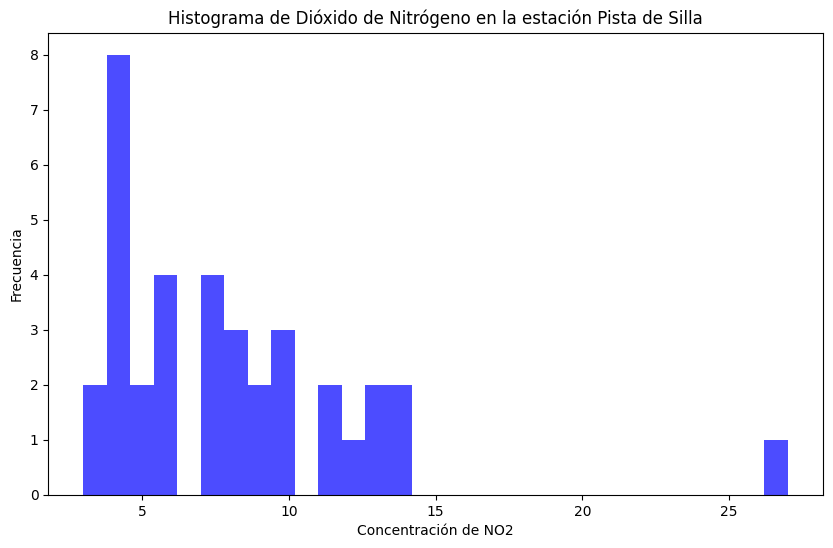

In [106]:
# Realizar el histograma de dióxido de nitrógeno de la estación del punto anterior
plt.figure(figsize=(10, 6)) # Seteo el tamaño de la figura con valor 10 de ancho y 6 de alto
plt.hist(df[df['nombre'] == max_co_station]['no2'].dropna(), bins=30, color='blue', alpha=0.7) # elimino nulos, bins # barras en histograma, alpha transparencia
plt.title(f'Histograma de Dióxido de Nitrógeno en la estación {max_co_station}')
plt.xlabel('Concentración de NO2')
plt.ylabel('Frecuencia')
plt.show()

## 05
Realizar gráfica con  la línea temporal de las mediciones de ozono de la estación del punto anterior.

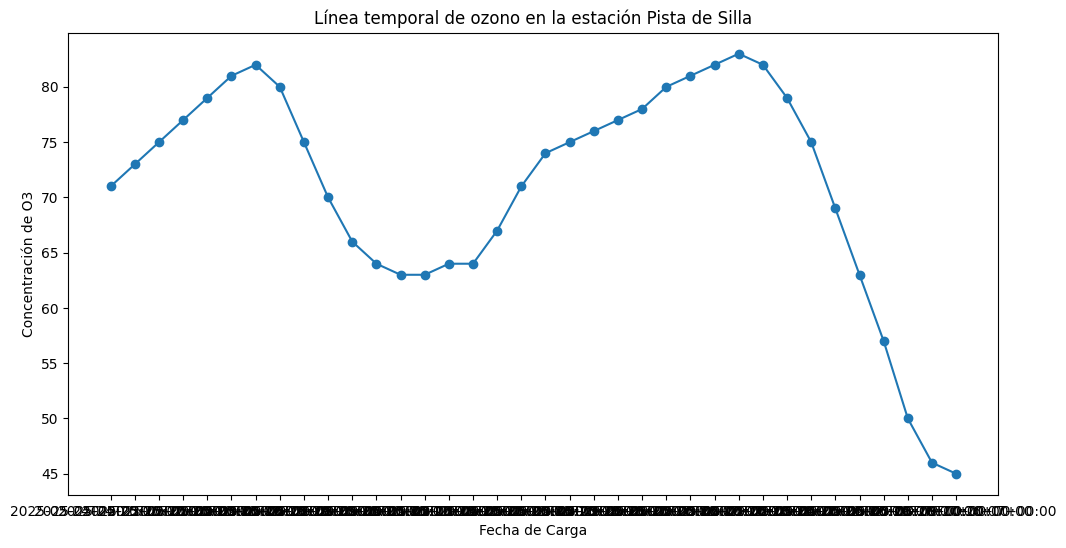

In [107]:
# Realizar gráfica con  la línea temporal de las mediciones de ozono de la estación del punto anterior.
plt.figure(figsize=(12, 6))
plt.plot(df[df['nombre'] == max_co_station]['fecha_carga'],
         df[df['nombre'] == max_co_station]['o3'], marker='o', linestyle='-')
plt.title(f'Línea temporal de ozono en la estación {max_co_station}')
plt.xlabel('Fecha de Carga')
plt.ylabel('Concentración de O3')
plt.show()